<a href="https://colab.research.google.com/github/diya-patel83/microbiome-disease-predictor/blob/diya-patel/analysis_cuml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.metrics import accuracy_score

In [44]:
df = pd.read_csv("sample_to_run_info.csv")

/tmp/ipykernel_902/2515147133.py:1: DtypeWarning: Columns (22,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_to_run_info.csv")


In [45]:
thresh = int(len(df) * 0.5)          # minimum non-null count to keep a column
df = df.dropna(axis=1, thresh=thresh)

In [46]:
# Check whether certain diseases are overrepresented on a given platform for instrument_model.
df

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
0,PRJDB3418,NaN,APr10S00,DRR028772,DRS020620,SAMD00024580,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
1,PRJDB3418,NaN,APr14S00,DRR028773,DRS020607,SAMD00024581,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
2,PRJDB3418,NaN,APr15S00,DRR028774,DRS020582,SAMD00024582,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
3,PRJDB3418,NaN,APr21S00,DRR028775,DRS020613,SAMD00024583,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
4,PRJDB3418,NaN,APr24S00,DRR028776,DRS020600,SAMD00024584,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118860,PRJNA556801,AIH_50,Sample30,SRR9851941,SRS5171228,SAMN12388878,AMPLICON,51320.0,Illumina MiSeq,D019693,"Hepatitis, Autoimmune",Y,China,1/4/2019 00:00:00,113.42,34.44
118861,PRJNA556801,HC_47,Sample84,SRR9851942,SRS5171227,SAMN12388932,AMPLICON,45711.0,Illumina MiSeq,D006262,Healthy,Y,China,1/3/2019 00:00:00,113.42,34.44
118862,PRJNA556801,AIH_38,Sample21,SRR9851943,SRS5171226,SAMN12388869,AMPLICON,60044.0,Illumina MiSeq,D019693,"Hepatitis, Autoimmune",Y,China,1/3/2019 00:00:00,113.42,34.44
118863,PRJNA556801,AIH_39,Sample22,SRR9851944,SRS5171225,SAMN12388870,AMPLICON,45185.0,Illumina MiSeq,D019693,"Hepatitis, Autoimmune",Y,China,1/3/2019 00:00:00,113.42,34.44


In [47]:
df['phenotype'].value_counts()

,count
phenotype,
Healthy,48241
Colorectal Neoplasms,5543
Crohn Disease,3516
COVID-19,2911
Parkinson Disease,2169
...,...
Colonic Polyps,5
Urolithiasis,5
Dry Eye Syndromes,4


In [48]:
# phenotype_counts = df['phenotype'].value_counts()
# valid_phenos = phenotype_counts[phenotype_counts >= 1000].index
# df = df[df['phenotype'].isin(valid_phenos)].copy()

keep_phenos = [
    "Healthy",
#     "Colorectal Neoplasms",
    "Crohn Disease",
    "Colitis, Ulcerative",
]

df = df[df["phenotype"].isin(keep_phenos)].copy()

In [49]:
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

df = df[df["project_id"].isin(project_ids)].copy()

print(df.shape)
print(df["phenotype"].value_counts())

(7478, 16)
phenotype
Crohn Disease          3516
Healthy                2099
Colitis, Ulcerative    1863
Name: count, dtype: int64


In [50]:
df['country'].value_counts()

,count
country,
United States of America,3698
China,970
Canada,666
Sweden,637
South Korea,263
Japan,196
Russia,168
Germany,167
India,101


In [51]:
df['experiment_type'].value_counts()

,count
experiment_type,
AMPLICON,4444
Metagenomics,3034


In [52]:
df

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
488,PRJDB6133,NaN,Fecal sample from healthy subject H11,DRR100552,DRS105572,SAMD00089771,AMPLICON,133593.0,Illumina MiSeq,D006262,Healthy,Y,Japan,1/1/2015 00:00:00,NaN,NaN
489,PRJDB6133,NaN,Fecal sample from healthy subject H19,DRR100553,DRS105573,SAMD00089772,AMPLICON,126764.0,Illumina MiSeq,D006262,Healthy,Y,Japan,1/1/2015 00:00:00,NaN,NaN
490,PRJDB6133,NaN,Fecal sample from healthy subject H20,DRR100554,DRS105574,SAMD00089773,AMPLICON,86207.0,Illumina MiSeq,D006262,Healthy,Y,Japan,1/1/2015 00:00:00,NaN,NaN
491,PRJDB6133,NaN,Fecal sample from healthy subject H21,DRR100555,DRS105575,SAMD00089774,AMPLICON,140281.0,Illumina MiSeq,D006262,Healthy,Y,Japan,1/1/2015 00:00:00,NaN,NaN
492,PRJDB6133,NaN,Fecal sample from healthy subject H22,DRR100556,DRS105576,SAMD00089775,AMPLICON,133962.0,Illumina MiSeq,D006262,Healthy,Y,Japan,1/1/2015 00:00:00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111248,PRJNA486505,7p,Inactive Crohn's disease ileal microbiota is l...,SRR7705883,SRS3679467,SAMN09848009,AMPLICON,40114.0,Illumina MiSeq,D003424,Crohn Disease,Y,Italy,1/1/2018 00:00:00,12.3,41.54
111249,PRJNA486505,7c,Inactive Crohn's disease ileal microbiota is l...,SRR7705884,SRS3679466,SAMN09848008,AMPLICON,529500.0,Illumina MiSeq,D006262,Healthy,Y,Italy,1/1/2018 00:00:00,12.3,41.54
111250,PRJNA486505,6p,Inactive Crohn's disease ileal microbiota is l...,SRR7705885,SRS3679465,SAMN09848007,AMPLICON,40100.0,Illumina MiSeq,D003424,Crohn Disease,Y,Italy,1/1/2018 00:00:00,12.3,41.54
111251,PRJNA486505,4c,Inactive Crohn's disease ileal microbiota is l...,SRR7705886,SRS3679464,SAMN09848002,AMPLICON,353014.0,Illumina MiSeq,D006262,Healthy,Y,Italy,1/1/2018 00:00:00,12.3,41.54


In [53]:
abundance = pd.read_csv('species_abundance.csv')

In [54]:
abundance

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.951900,DRR358335
1,2,81104,544,genus,1.074570,DRR358335
2,3,81104,561,genus,0.849570,DRR358335
3,4,81104,570,genus,0.062180,DRR358335
4,5,81104,816,genus,23.296990,DRR358335
...,...,...,...,...,...,...
5541266,5541267,774,1980681,genus,0.286862,SRR9951896
5541267,5541268,774,2039302,genus,0.755403,SRR9951896
5541268,5541269,774,2316020,genus,1.415185,SRR9951896
5541269,5541270,774,2742598,genus,0.984892,SRR9951896


In [55]:
abundance['taxon_rank_level'].value_counts()

,count
taxon_rank_level,
genus,2780064
species,2761207


In [56]:
# Keep only genus level
abund_genus = abundance[abundance["taxon_rank_level"] == "genus"].copy()

# Drop rows with ncbi_taxon_id = -1 (unassigned/other)
abund_genus = abund_genus[abund_genus["ncbi_taxon_id"] != -1].copy()

In [57]:
# Pivot: run_id x ncbi_taxon_id, values = relative_abundance
abund_wide = (
    abund_genus
    .pivot_table(index="accession_id",      # this matches run_id in df
                 columns="ncbi_taxon_id",
                 values="relative_abundance",
                 aggfunc="sum",
                 fill_value=0.0)
    .reset_index()
)

# Make column names nicer (e.g., taxon_544, taxon_561, ...)
abund_wide.columns = [
    "run_id" if c == "accession_id" else f"taxon_{int(c)}"
    for c in abund_wide.columns
]

In [58]:
abundance

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.951900,DRR358335
1,2,81104,544,genus,1.074570,DRR358335
2,3,81104,561,genus,0.849570,DRR358335
3,4,81104,570,genus,0.062180,DRR358335
4,5,81104,816,genus,23.296990,DRR358335
...,...,...,...,...,...,...
5541266,5541267,774,1980681,genus,0.286862,SRR9951896
5541267,5541268,774,2039302,genus,0.755403,SRR9951896
5541268,5541269,774,2316020,genus,1.415185,SRR9951896
5541269,5541270,774,2742598,genus,0.984892,SRR9951896


In [59]:
merged = df.merge(abund_wide, on="run_id", how="inner")

In [60]:
merged

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,...,taxon_3090883,taxon_3109381,taxon_3119832,taxon_3120720,taxon_3120725,taxon_3120754,taxon_3121626,taxon_3277338,taxon_3373482,taxon_3409995
0,PRJDB6133,NaN,Fecal sample from healthy subject H11,DRR100552,DRS105572,SAMD00089771,AMPLICON,133593.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PRJDB6133,NaN,Fecal sample from healthy subject H19,DRR100553,DRS105573,SAMD00089772,AMPLICON,126764.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PRJDB6133,NaN,Fecal sample from healthy subject H21,DRR100555,DRS105575,SAMD00089774,AMPLICON,140281.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PRJDB6133,NaN,Fecal sample from healthy subject H22,DRR100556,DRS105576,SAMD00089775,AMPLICON,133962.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PRJDB6133,NaN,Fecal sample from healthy subject H23,DRR100557,DRS105577,SAMD00089776,AMPLICON,127410.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3808,PRJNA429990,U107F,U107F,SRR6504919,SRS2861074,SAMN08382853,Metagenomics,118735787.0,HiSeq X Ten,D003093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3809,PRJNA429990,C115F,C115F,SRR6504920,SRS2861075,SAMN08382802,Metagenomics,48872002.0,HiSeq X Ten,D003424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3810,PRJNA429990,C114F,C114F,SRR6504921,SRS2861077,SAMN08382801,Metagenomics,45104993.0,HiSeq X Ten,D003424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3811,PRJNA429990,U234F,U234F,SRR6504922,SRS2861080,SAMN08382873,Metagenomics,22414787.0,HiSeq X Ten,D003093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [62]:
keep_phenos = ["Healthy", "Crohn Disease", "Colitis, Ulcerative"]
df3 = merged[merged["phenotype"].isin(keep_phenos)].copy()

label_map = {
    "Healthy": 0,
    "Crohn Disease": 1,
    "Colitis, Ulcerative": 2,
}
df3["label"] = df3["phenotype"].map(label_map)

taxon_cols = [c for c in df3.columns if c.startswith("taxon_")]

gdf = cudf.from_pandas(df3[["label"] + taxon_cols])

X = gdf[taxon_cols]
y = gdf["label"]

In [63]:
from sklearn.model_selection import train_test_split

X_pd = df3[taxon_cols].values
y_pd = df3["label"].values

X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(
    X_pd, y_pd, test_size=0.2, stratify=y_pd, random_state=42
)

X_train = cudf.DataFrame(X_train_pd, columns=taxon_cols)
X_test  = cudf.DataFrame(X_test_pd,  columns=taxon_cols)
y_train = cudf.Series(y_train_pd)
y_test  = cudf.Series(y_test_pd)

In [64]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = cuLogisticRegression(
    penalty="l1",
    C=0.1,                 # tune for sparsity
    l1_ratio=None,         # pure L1
    fit_intercept=True,
    class_weight="balanced",
    max_iter=5000,
    solver="qn",           # cuML solver
    verbose=0
)

In [65]:
clf.fit(X_train_scaled, y_train)

LogisticRegression()

In [66]:
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("GPU multinomial L1-logreg accuracy:", float(acc))

GPU multinomial L1-logreg accuracy: 0.6081258191349934


In [67]:
# coef_ is a cuDF DataFrame: shape (n_classes, n_features)
coefs_cudf = clf.coef_

# Convert to pandas / NumPy
coefs = coefs_cudf.to_pandas().to_numpy()   # (n_classes, n_features)

# classes_ is already a NumPy array (e.g., array([0, 1, 2]))
classes = clf.classes_

# Union of non-zero features across classes
nz_any = (coefs != 0).any(axis=0)
selected_taxa_union = np.array(taxon_cols)[nz_any]

print("Total taxa:", len(taxon_cols))
print("Selected by LASSO (any class):", len(selected_taxa_union))

selected_df = pd.DataFrame({
    "taxon": selected_taxa_union,
    "coef_l1_sum": np.abs(coefs[:, nz_any]).sum(axis=0)
}).sort_values("coef_l1_sum", ascending=False)

print(selected_df.head(30))


Total taxa: 2213
Selected by LASSO (any class): 413
             taxon  coef_l1_sum
355  taxon_2719313     0.798832
225  taxon_1080709     0.724749
407  taxon_2983509     0.465434
346  taxon_2591381     0.373801
184   taxon_283168     0.344858
206   taxon_577310     0.327169
100    taxon_35832     0.299270
185   taxon_292632     0.295641
176   taxon_239759     0.291270
348  taxon_2678884     0.287027
148   taxon_156973     0.277547
393  taxon_2944194     0.272889
322  taxon_2039302     0.270844
54      taxon_1578     0.267627
317  taxon_2005473     0.267538
371  taxon_2815777     0.266267
48      taxon_1301     0.261091
398  taxon_2944199     0.260427
203   taxon_572511     0.259034
314  taxon_1987748     0.252240
315  taxon_2005355     0.251901
277  taxon_1903506     0.232602
208   taxon_580596     0.230228
99     taxon_35583     0.229059
310  taxon_1980693     0.220259
27       taxon_816     0.217945
302  taxon_1935200     0.212384
311  taxon_1980697     0.211608
170   taxon_209879  

In [68]:
full_lasso = pd.concat(
    [df3.drop(columns=taxon_cols), df3[selected_taxa_union]],
    axis=1
)

In [69]:
full_lasso

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,...,taxon_2983247,taxon_2983249,taxon_2983250,taxon_2983459,taxon_2983509,taxon_2992720,taxon_2994443,taxon_2995122,taxon_3025755,taxon_3028852
0,PRJDB6133,NaN,Fecal sample from healthy subject H11,DRR100552,DRS105572,SAMD00089771,AMPLICON,133593.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PRJDB6133,NaN,Fecal sample from healthy subject H19,DRR100553,DRS105573,SAMD00089772,AMPLICON,126764.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PRJDB6133,NaN,Fecal sample from healthy subject H21,DRR100555,DRS105575,SAMD00089774,AMPLICON,140281.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PRJDB6133,NaN,Fecal sample from healthy subject H22,DRR100556,DRS105576,SAMD00089775,AMPLICON,133962.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PRJDB6133,NaN,Fecal sample from healthy subject H23,DRR100557,DRS105577,SAMD00089776,AMPLICON,127410.0,Illumina MiSeq,D006262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3808,PRJNA429990,U107F,U107F,SRR6504919,SRS2861074,SAMN08382853,Metagenomics,118735787.0,HiSeq X Ten,D003093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3809,PRJNA429990,C115F,C115F,SRR6504920,SRS2861075,SAMN08382802,Metagenomics,48872002.0,HiSeq X Ten,D003424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3810,PRJNA429990,C114F,C114F,SRR6504921,SRS2861077,SAMN08382801,Metagenomics,45104993.0,HiSeq X Ten,D003424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3811,PRJNA429990,U234F,U234F,SRR6504922,SRS2861080,SAMN08382873,Metagenomics,22414787.0,HiSeq X Ten,D003093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
print(full_lasso.shape)
print(full_lasso["phenotype"].value_counts())

(3813, 430)
phenotype
Crohn Disease          1748
Colitis, Ulcerative    1063
Healthy                1002
Name: count, dtype: int64


In [71]:
# full_lasso: pandas df with selected_taxa_union + 'label'
feature_cols = list(selected_taxa_union)

X = full_lasso[feature_cols].values
y = full_lasso["label"].values  # 0=Healthy,1=Crohn,2=UC

In [72]:
# Train/test split on CPU first
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Move to GPU (cuDF)
X_train = cudf.DataFrame(X_train_np, columns=feature_cols)
X_test  = cudf.DataFrame(X_test_np,  columns=feature_cols)
y_train = cudf.Series(y_train_np)
y_test  = cudf.Series(y_test_np)

In [73]:
# Move to GPU (cuDF)
X_train = cudf.DataFrame(X_train_np, columns=feature_cols)
X_test  = cudf.DataFrame(X_test_np,  columns=feature_cols)
y_train = cudf.Series(y_train_np)
y_test  = cudf.Series(y_test_np)

rf = cuRF(
    n_estimators=300,
    max_depth=20,       # <- set an explicit int, not None
    max_features=1.0,   # fraction of features; 1.0 ~ use all
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

In [74]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [75]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("GPU RandomForest accuracy:", float(acc))

GPU RandomForest accuracy: 0.7614678899082569


In [76]:
# Feature importances
importances = rf.feature_importances_
idx = importances.argsort()[::-1]

top_k = 30
top_feats = [(feature_cols[i], importances[i]) for i in idx[:top_k]]

top_importance_df = pd.DataFrame(top_feats, columns=["taxon", "rf_importance"])
print(top_importance_df)

            taxon  rf_importance
0   taxon_2981631       0.031921
1   taxon_2944152       0.027853
2   taxon_2316020       0.027463
3   taxon_2719313       0.024733
4    taxon_216851       0.021919
5    taxon_283168       0.020793
6    taxon_204475       0.019635
7       taxon_816       0.018561
8    taxon_909656       0.016801
9     taxon_28050       0.016377
10   taxon_572511       0.015809
11     taxon_1678       0.015620
12     taxon_1301       0.015530
13  taxon_2892396       0.015529
14    taxon_39948       0.014397
15    taxon_40544       0.014308
16  taxon_2974251       0.014253
17   taxon_207244       0.013946
18   taxon_239759       0.013945
19  taxon_1407607       0.013320
20   taxon_375288       0.013242
21  taxon_2039302       0.012715
22  taxon_2005355       0.012636
23     taxon_1730       0.012404
24     taxon_1485       0.012190
25    taxon_35832       0.011842
26  taxon_2815777       0.011617
27  taxon_2591381       0.011517
28      taxon_841       0.011295
29     tax

In [77]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

In [78]:
# full_lasso: pandas df with selected_taxa_union and "label" (0=Healthy,1=Crohn,2=UC)
feature_cols = list(selected_taxa_union)

X = full_lasso[feature_cols].values
y = full_lasso["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

In [79]:
params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "tree_method": "hist",   # GPU acceleration
    "predictor": "gpu_predictor",
    "max_depth": 6,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "mlogloss",
    "device": "cuda",
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=30,
    verbose_eval=False,
)

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:14:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [80]:
y_proba = bst.predict(dtest)              # shape (n_samples, 3)
y_pred = np.argmax(y_proba, axis=1)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.69      0.72       200
           1       0.75      0.87      0.81       350
           2       0.76      0.61      0.68       213

    accuracy                           0.75       763
   macro avg       0.75      0.72      0.73       763
weighted avg       0.75      0.75      0.75       763



In [81]:
# Macro-averaged ROC-AUC (one-vs-rest)
y_test_oh = np.eye(3)[y_test]
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr")
print("Macro ROC-AUC:", auc)

Macro ROC-AUC: 0.8990429670215475


In [82]:
# Feature importance
importance = bst.get_score(importance_type="gain")
# importance is a dict {"f0":gain,...} where f{i} maps to feature_cols[i]
items = []
for k, v in importance.items():
    idx = int(k[1:])  # drop 'f'
    items.append((feature_cols[idx], v))

In [83]:
imp_df = pd.DataFrame(items, columns=["taxon", "gain"]).sort_values("gain", ascending=False)
print(imp_df.head(30))

             taxon       gain
223  taxon_2944152  15.046545
141  taxon_1729679   9.335573
200  taxon_2683202   7.042379
24       taxon_953   5.641717
15       taxon_830   5.089970
78    taxon_156973   3.707180
225  taxon_2944194   3.681943
173  taxon_2005355   3.664639
16       taxon_836   3.484381
88    taxon_204475   3.457283
153  taxon_1918452   3.349450
198  taxon_2678884   3.328771
119  taxon_1080709   3.300982
177  taxon_2023266   3.231849
99    taxon_292632   3.197818
222  taxon_2944150   3.172145
156  taxon_1918598   2.928198
209  taxon_2767842   2.804818
234  taxon_2983509   2.794347
138  taxon_1635148   2.791317
29      taxon_1279   2.783828
175  taxon_2005473   2.779265
82    taxon_165779   2.723727
85    taxon_184869   2.691312
98    taxon_283168   2.654491
84    taxon_177971   2.597837
215  taxon_2892396   2.557835
212  taxon_2813348   2.491760
35      taxon_1578   2.464705
164  taxon_1935176   2.461882


In [84]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [85]:
class_names = ["Healthy", "Crohn", "UC"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(title)
    print(classification_report(y_true, y_pred, target_names=class_names))

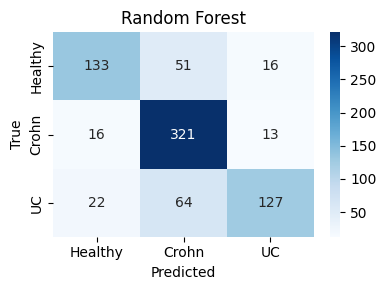

Random Forest
              precision    recall  f1-score   support

     Healthy       0.78      0.67      0.72       200
       Crohn       0.74      0.92      0.82       350
          UC       0.81      0.60      0.69       213

    accuracy                           0.76       763
   macro avg       0.78      0.73      0.74       763
weighted avg       0.77      0.76      0.75       763



In [86]:
# 2) Random Forest (cuML or sklearn)
# If you used cuML:
y_pred_rf = rf.predict(X_test)   # X_test_gpu = cuDF, convert to NumPy
# If sklearn RF: y_pred_rf = rf.predict(X_test)
plot_cm(y_test_np, y_pred_rf, "Random Forest")      # y_test_np = NumPy labels

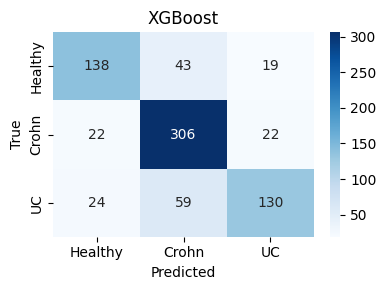

XGBoost
              precision    recall  f1-score   support

     Healthy       0.75      0.69      0.72       200
       Crohn       0.75      0.87      0.81       350
          UC       0.76      0.61      0.68       213

    accuracy                           0.75       763
   macro avg       0.75      0.72      0.73       763
weighted avg       0.75      0.75      0.75       763



In [87]:
y_proba_xgb = bst.predict(dtest)                    # dtest = XGBoost DMatrix
y_pred_xgb = np.argmax(y_proba_xgb, axis=1)
plot_cm(y_test, y_pred_xgb, "XGBoost")

In [88]:
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

print(f"Projects with at least one Crohn Disease or Ulcerative Colitis sample: {len(project_ids)}")
print(project_ids)

Projects with at least one Crohn Disease or Ulcerative Colitis sample: 46
['PRJDB6133' 'PRJEB76677' 'PRJEB14288' 'PRJEB3206' 'PRJEB18471'
 'PRJEB21933' 'PRJEB23009' 'PRJEB39813' 'PRJEB33711' 'PRJEB6172'
 'PRJEB42151' 'PRJNA600852' 'PRJNA646271' 'PRJNA647405' 'PRJNA648093'
 'PRJNA679275' 'PRJNA718382' 'PRJNA737297' 'PRJNA257186' 'PRJNA783859'
 'PRJNA793776' 'PRJNA804422' 'PRJNA820056' 'PRJNA851554' 'PRJNA884507'
 'PRJNA813736' 'PRJNA909073' 'PRJNA917086' 'PRJNA935155' 'PRJNA938107'
 'PRJNA975689' 'PRJNA983946' 'PRJNA986689' 'PRJNA296946' 'PRJNA1007787'
 'PRJNA1024059' 'PRJNA1024678' 'PRJNA1029396' 'PRJNA993675' 'PRJNA1053658'
 'PRJNA1062375' 'PRJNA304009' 'PRJNA1156939' 'PRJNA398089' 'PRJNA429990'
 'PRJNA486505']


In [89]:
# Binary Model: Crohn vs UC (no Healthy)

# Step 1: Filter to IBD only
ibd_only = full_lasso[full_lasso["phenotype"].isin(["Crohn Disease", "Colitis, Ulcerative"])].copy()

binary_label_map = {"Crohn Disease": 0, "Colitis, Ulcerative": 1}
ibd_only["binary_label"] = ibd_only["phenotype"].map(binary_label_map)

print("IBD-only class distribution:")
print(ibd_only["phenotype"].value_counts())
# Expected: Crohn ~3516, UC ~1863

# Step 2: Features + labels
feature_cols = list(selected_taxa_union)
X_ibd = ibd_only[feature_cols].values
y_ibd = ibd_only["binary_label"].values

# Step 3: Train/test split
X_train_ibd, X_test_ibd, y_train_ibd, y_test_ibd = train_test_split(
    X_ibd, y_ibd, test_size=0.2, stratify=y_ibd, random_state=42
)

print(f"\nTrain: {len(X_train_ibd)} samples")
print(f"Test:  {len(X_test_ibd)} samples")

IBD-only class distribution:
phenotype
Crohn Disease          1748
Colitis, Ulcerative    1063
Name: count, dtype: int64

Train: 2248 samples
Test:  563 samples


In [90]:
# Step 4: XGBoost binary
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

dtrain_ibd = xgb.DMatrix(X_train_ibd, label=y_train_ibd)
dtest_ibd  = xgb.DMatrix(X_test_ibd,  label=y_test_ibd)

params_binary = {
    "objective": "binary:logistic",   # binary now, not multi:softprob
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "auc",             # AUC is best metric for binary
}

bst_ibd = xgb.train(
    params_binary,
    dtrain_ibd,
    num_boost_round=500,
    evals=[(dtrain_ibd, "train"), (dtest_ibd, "test")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

[0]	train-auc:0.79570	test-auc:0.70143
[50]	train-auc:0.97635	test-auc:0.86688
[100]	train-auc:0.98911	test-auc:0.88267
[150]	train-auc:0.99534	test-auc:0.89286
[200]	train-auc:0.99802	test-auc:0.89714
[250]	train-auc:0.99894	test-auc:0.90038
[300]	train-auc:0.99955	test-auc:0.90848
[350]	train-auc:0.99978	test-auc:0.91084
[400]	train-auc:0.99990	test-auc:0.91172
[450]	train-auc:0.99995	test-auc:0.91254
[461]	train-auc:0.99995	test-auc:0.91253


XGBoost — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.85      0.89      0.87       350
          UC       0.81      0.73      0.77       213

    accuracy                           0.83       563
   macro avg       0.83      0.81      0.82       563
weighted avg       0.83      0.83      0.83       563

ROC-AUC: 0.9125


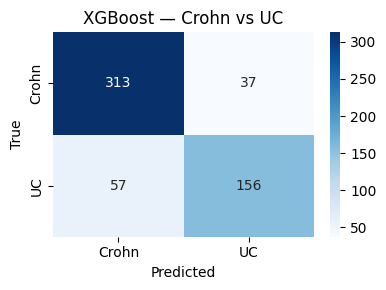

In [94]:
# Step 5: Evaluate XGBoost binary
y_proba_ibd = bst_ibd.predict(dtest_ibd)
y_pred_ibd  = (y_proba_ibd > 0.5).astype(int)

print("XGBoost — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_ibd, target_names=["Crohn", "UC"]))
print(f"ROC-AUC: {roc_auc_score(y_test_ibd, y_proba_ibd):.4f}")

# Use a separate plot function for binary — don't use plot_cm
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm_binary(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Crohn", "UC"],
                yticklabels=["Crohn", "UC"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm_binary(y_test_ibd, y_pred_ibd, "XGBoost — Crohn vs UC")

Random Forest — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.82      0.92      0.87       350
          UC       0.84      0.67      0.74       213

    accuracy                           0.83       563
   macro avg       0.83      0.80      0.81       563
weighted avg       0.83      0.83      0.82       563



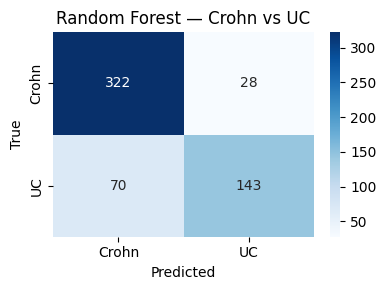

In [96]:
# Step 6: Random Forest binary
rf_ibd = cuRF(
    n_estimators=300,
    max_depth=20,
    max_features=1.0,
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

X_train_ibd_gpu = cudf.DataFrame(X_train_ibd, columns=feature_cols)
X_test_ibd_gpu  = cudf.DataFrame(X_test_ibd,  columns=feature_cols)
y_train_ibd_gpu = cudf.Series(y_train_ibd)
y_test_ibd_gpu  = cudf.Series(y_test_ibd)

rf_ibd.fit(X_train_ibd_gpu, y_train_ibd_gpu)
y_pred_rf_ibd = rf_ibd.predict(X_test_ibd_gpu)

print("Random Forest — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_rf_ibd.to_numpy(), target_names=["Crohn", "UC"]))

plot_cm_binary(y_test_ibd, y_pred_rf_ibd.to_numpy(), "Random Forest — Crohn vs UC")

Default threshold (0.5): F1 = 0.7685
Optimal threshold (0.32): F1 = 0.8000

Tuned threshold results:
              precision    recall  f1-score   support

       Crohn       0.92      0.80      0.86       350
          UC       0.73      0.88      0.80       213

    accuracy                           0.83       563
   macro avg       0.82      0.84      0.83       563
weighted avg       0.85      0.83      0.83       563



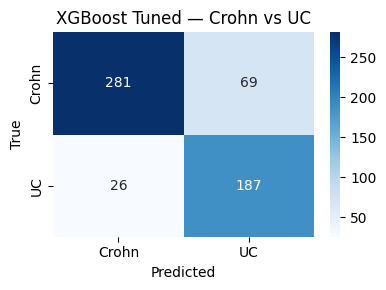

In [97]:
# Step 7: Threshold tuning — find optimal cutoff for UC recall
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test_ibd, y_proba_ibd)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores.argmax()]

print(f"Default threshold (0.5): F1 = {f1_score(y_test_ibd, (y_proba_ibd > 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}): F1 = {f1_scores.max():.4f}")

# Apply optimal threshold
y_pred_tuned = (y_proba_ibd > best_thresh).astype(int)
print("\nTuned threshold results:")
print(classification_report(y_test_ibd, y_pred_tuned, target_names=["Crohn", "UC"]))
plot_cm_binary(y_test_ibd, y_pred_tuned, "XGBoost Tuned — Crohn vs UC")